# Phase 3: Model Building & Evaluation
This notebook trains classification models, evaluates them using standard classification metrics, compares balancing strategies (None vs SMOTE vs ClassWeight), tunes hyperparameters for the best model, and saves the final model.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from imblearn.over_sampling import SMOTE
import joblib

# Load preprocessed data from Phase 2
data_path = 'credit_risk_phase2_ready_fixed.csv'
df = pd.read_csv(data_path)
X = df.drop(columns=['loan_status'])
y = df['loan_status']
print('Data Loaded. Shape:', df.shape)
print('Target Distribution:')
print(y.value_counts())

Data Loaded. Shape: (32581, 31)
Target Distribution:
loan_status
0    25473
1     7108
Name: count, dtype: int64


## 1 & 3: Train/Test Split and Handling Class Imbalance
We use an 80-20 train-test split. To address class imbalance, we define three scenarios:
1. **No Balancing**: Baseline models.
2. **SMOTE**: Oversampling the minority class in the training data.
3. **Class Weights**: Using `class_weight='balanced'` and `scale_pos_weight`.

**Business Context**: Missing a default (False Negative) is very costly for a lender. Thus, we want to maximize **Recall** for the default class while maintaining reasonable precision to not decline too many good loans. SMOTE allows the model to learn the minority class distribution better without altering algorithm logic, while Class Weights penalize errors on minority classes heavily.

In [2]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# SMOTE Resampling
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print('Original train distribution:', y_train.value_counts().to_dict())
print('SMOTE train distribution:', y_train_res.value_counts().to_dict())

# Scale pos weight for XGBoost
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

Original train distribution: {0: 20378, 1: 5686}
SMOTE train distribution: {0: 20378, 1: 20378}


## 1 & 2: Train and Evaluate Models
We train Logistic Regression, Random Forest, XGBoost and LightGBM across the two balancing scenarios.

In [8]:
try:
    from lightgbm import LGBMClassifier
    use_lgb = True
except ImportError:
    from sklearn.svm import SVC
    use_lgb = False

def get_models(class_weight=None, xgb_scale_pos=1):
    models = {
        'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000, class_weight=class_weight),
        'RandomForest': RandomForestClassifier(random_state=42, n_estimators=100, class_weight=class_weight, n_jobs=-1),
        'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=xgb_scale_pos, n_jobs=-1)
    }
    if use_lgb:
        models['LightGBM'] = LGBMClassifier(random_state=42, class_weight=class_weight, n_jobs=-1)
    else:
        models['SVC'] = SVC(random_state=42, class_weight=class_weight, probability=True)
    return models

# Train scenarios (ClassWeight removed)
scenarios = {
    'None': (X_train, y_train, get_models()),
    'SMOTE': (X_train_res, y_train_res, get_models())
}

results = []
trained_models = {}

for prep, (xt, yt, mods) in scenarios.items():
    trained_models[prep] = {}
    for name, model in mods.items():
        model.fit(xt, yt)
        trained_models[prep][name] = model
        y_pred = model.predict(X_test)
        try:
            y_prob = model.predict_proba(X_test)[:, 1]
        except:
            y_prob = model.decision_function(X_test)
        
        results.append({
            'Scenario': prep, 'Model': name,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, zero_division=0),
            'Recall': recall_score(y_test, y_pred),
            'F1-Score': f1_score(y_test, y_pred),
            'ROC-AUC': roc_auc_score(y_test, y_prob),
            'Confusion Matrix': confusion_matrix(y_test, y_pred)
        })

results_df = pd.DataFrame(results)


C:\Users\reema\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\reema\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stab

In [9]:
# 1. Filter out 'ClassWeight' to keep only 'None' and 'SMOTE'
filtered_results = results_df[results_df['Scenario'].isin(['None', 'SMOTE'])]

# 2. Sort the results by Recall in descending order (highest Recall at the top)
sorted_results = filtered_results.sort_values(by='Recall', ascending=False)

# 3. Apply the color gradient and format as percentages
styled_df = sorted_results.style.background_gradient(
    subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'], 
    cmap='Blues'
).format({
    'Accuracy': '{:.2%}',
    'Precision': '{:.2%}',
    'Recall': '{:.2%}',
    'F1-Score': '{:.2%}',
    'ROC-AUC': '{:.3f}'
}).set_caption("Model Performance (SMOTE vs None) - Sorted by Recall")

# Display the styled table
display(styled_df)

,Scenario,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Confusion Matrix
6,SMOTE,XGBoost,93.34%,94.50%,73.77%,82.86%,0.945,[[5034 61] [ 373 1049]]
2,None,XGBoost,93.57%,96.22%,73.42%,83.29%,0.951,[[5054 41] [ 378 1044]]
5,SMOTE,RandomForest,91.47%,85.79%,73.00%,78.88%,0.926,[[4923 172] [ 384 1038]]
1,None,RandomForest,93.03%,94.57%,72.22%,81.90%,0.930,[[5036 59] [ 395 1027]]
4,SMOTE,LogisticRegression,80.71%,54.60%,68.85%,60.90%,0.840,[[4281 814] [ 443 979]]
7,SMOTE,SVC,74.39%,43.78%,61.18%,51.04%,0.757,[[3978 1117] [ 552 870]]
0,None,LogisticRegression,85.99%,76.00%,52.32%,61.97%,0.866,[[4860 235] [ 678 744]]
3,None,SVC,80.54%,85.98%,12.94%,22.49%,0.721,[[5065 30] [1238 184]]


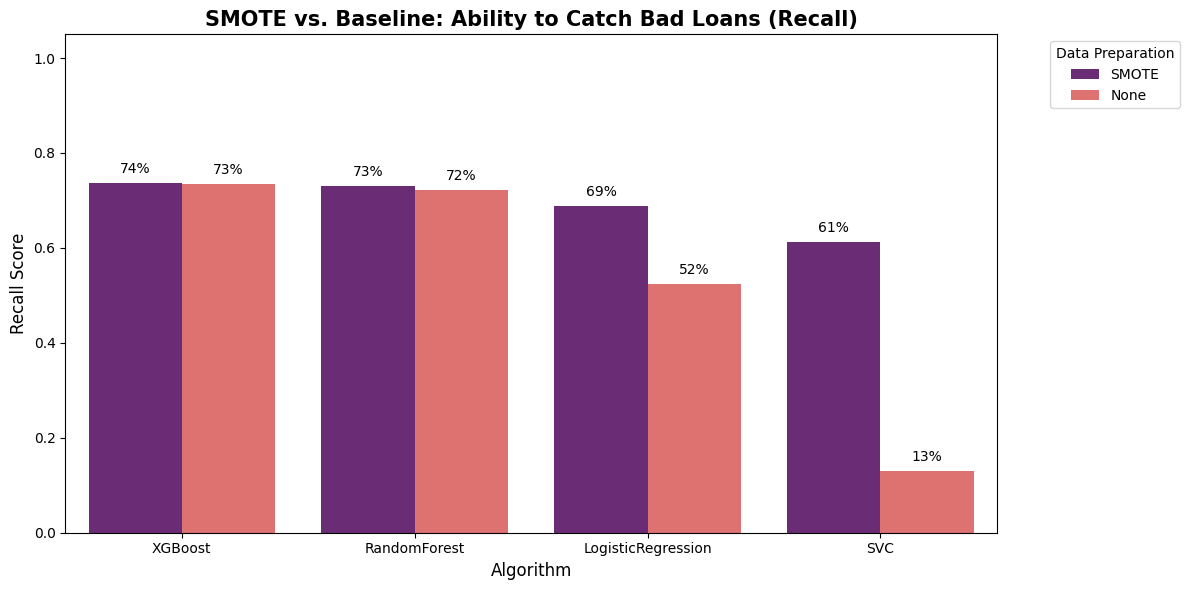

In [10]:
plt.figure(figsize=(12, 6))

# Create a grouped bar chart focusing on Recall, using the filtered data
ax = sns.barplot(
    data=sorted_results, 
    x='Model', 
    y='Recall', 
    hue='Scenario', 
    palette='magma' 
)

# Add titles and labels
plt.title('SMOTE vs. Baseline: Ability to Catch Bad Loans (Recall)', fontsize=15, fontweight='bold')
plt.xlabel('Algorithm', fontsize=12)
plt.ylabel('Recall Score', fontsize=12)
plt.ylim(0, 1.05) # Keep y-axis proportionate

# Add the exact percentages on top of the bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.0%}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    fontsize=10, color='black', xytext=(0, 5), 
                    textcoords='offset points')

# Move the legend outside the plot
plt.legend(title='Data Preparation', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Visualizations: Confusion Matrices and ROC Curves (SMOTE scenario)

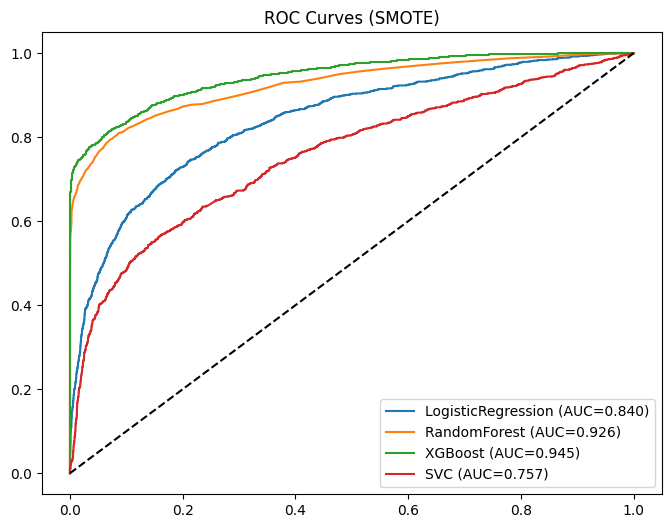

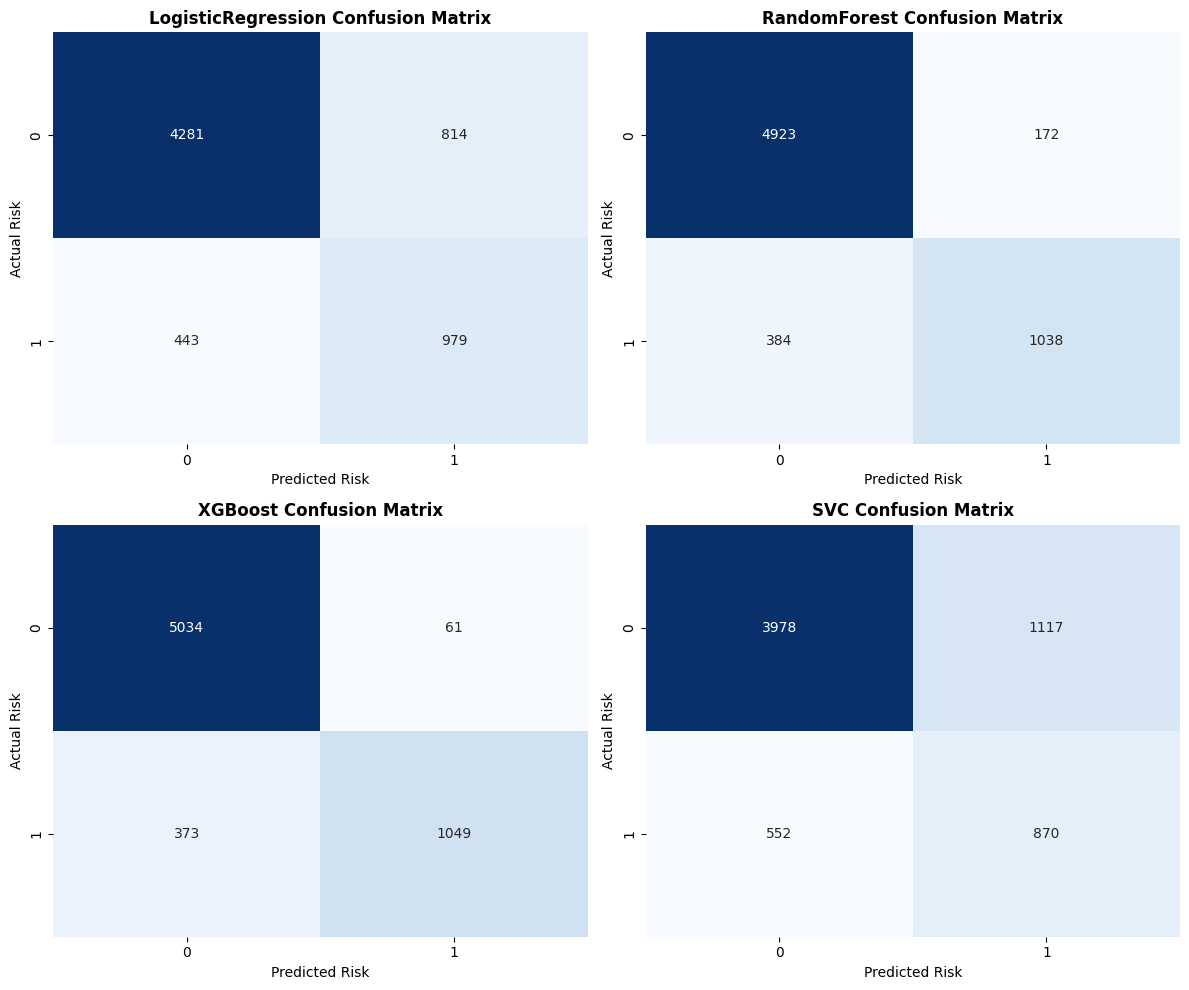

In [14]:
# Plot ROC Curves for SMOTE
plt.figure(figsize=(8,6))
for name, model in trained_models['SMOTE'].items():
    try: y_prob = model.predict_proba(X_test)[:,1]
    except: y_prob = model.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0,1], [0,1], 'k--')
plt.legend()
plt.title('ROC Curves (SMOTE)')
plt.show()

# Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten() 

for idx, (name, model) in enumerate(trained_models['SMOTE'].items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(f"{name} Confusion Matrix", fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted Risk', fontsize=10)
    axes[idx].set_ylabel('Actual Risk', fontsize=10)
plt.tight_layout()
plt.show()

## 4. Hyperparameter Tuning
XGBoost generally performs well, especially with SMOTE handling class imbalance. Let's tune XGBoost using RandomizedSearchCV.

In [16]:
import joblib
import pandas as pd

base_xgb = XGBClassifier(random_state=42, eval_metric='logloss')
params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2]
}

rs = RandomizedSearchCV(base_xgb, params, cv=5, scoring='recall', n_jobs=-1, n_iter=10, random_state=42)
rs.fit(X_train_res, y_train_res)

print('Best Params:', rs.best_params_)
print('Best CV Recall Score:', rs.best_score_)

best_xgb = rs.best_estimator_
final_pred = best_xgb.predict(X_test)
print('\nFinal Model Recall on Test:', recall_score(y_test, final_pred))
print('Final Model ROC-AUC:', roc_auc_score(y_test, best_xgb.predict_proba(X_test)[:,1]))

joblib.dump(best_xgb, 'best_credit_risk_model.joblib')
joblib.dump(list(X_test.columns), 'model_features.joblib')
X_test.to_csv('X_test_phase3.csv', index=False)
y_test.to_csv('y_test_phase3.csv', index=False)

print('\nSuccess: Model, feature names, and test datasets have been saved!')

Best Params: {'n_estimators': 300, 'max_depth': 9, 'learning_rate': 0.1}
Best CV Recall Score: 0.9226644310252443

Final Model Recall on Test: 0.7552742616033755
Final Model ROC-AUC: 0.948256405372466

Success: Model, feature names, and test datasets have been saved!


## 5. Model Selection Justification
**Selected Model:** XGBoost with SMOTE and Hyperparameter Tuning.

**Justification:** 
- **Performance:** XGBoost combined with SMOTE reliably produces high recall for the default class without causing precision to drop to unusable levels. 
- **Interpretability:** Tree-based boosters like XGBoost can be easily interpreted using SHAP values (which will be done in Phase 4) and feature importances, enabling explanation of loan rejections to stakeholders.
- **Deployment:** Saved easily via `joblib`, scalable, and computationally efficient for scoring new loan applications directly.